# Data and Sampling Distributions

Notebook ini merangkum Chapter 2 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas konsep **sampling**, **sample bias**, **sampling distribution**, **bootstrap**, **confidence interval**, serta beberapa distribusi penting yang sering digunakan dalam statistik dan data science.

Pembahasan dibuat mengikuti format notebook sebelumnya: terdapat tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami perbedaan antara population, sample, data distribution, dan sampling distribution.
- Menjelaskan random sampling, stratified sampling, sample bias, dan selection bias.
- Memahami mengapa kualitas data dan representativeness sering lebih penting daripada ukuran data.
- Menjelaskan regression to the mean sebagai akibat dari pemilihan nilai ekstrem.
- Memahami sampling distribution dan Central Limit Theorem.
- Menghitung standard error dari sample statistic.
- Menggunakan bootstrap untuk mengestimasi sampling distribution dan confidence interval.
- Memahami normal distribution, standard normal, z-score, dan QQ-Plot.
- Mengenali long-tailed distributions sebagai pola yang umum pada data nyata.
- Memahami fungsi dasar t-distribution, binomial distribution, chi-square distribution, F-distribution, Poisson distribution, exponential distribution, dan Weibull distribution.

## Ringkasan Chapter

Chapter ini menjelaskan bahwa sampling tetap penting meskipun data science sering bekerja dengan big data. Jumlah data yang besar tidak otomatis menjamin hasil analisis yang baik jika data tersebut bias, tidak representatif, atau memiliki kualitas buruk. Sampling yang baik dapat membantu mengurangi bias dan membuat eksplorasi data lebih efisien.

Pembahasan awal berfokus pada random sampling dan sample bias. Random sampling memberi peluang yang sama bagi setiap anggota population untuk terpilih. Jika proses pemilihan data tidak representatif, hasil analisis dapat mengarah pada sample bias. Chapter ini juga membahas selection bias, data snooping, vast search effect, dan regression to the mean.

Bagian berikutnya membahas sampling distribution. Sampling distribution adalah distribusi dari sample statistic yang diperoleh dari banyak sample. Chapter menjelaskan bahwa distribusi sample statistic, seperti sample mean, biasanya lebih teratur dan lebih sempit dibanding distribusi data mentah. Central Limit Theorem menjelaskan kecenderungan sample mean menjadi mendekati normal ketika sample size membesar.

Bootstrap diperkenalkan sebagai metode praktis untuk mengestimasi sampling distribution tanpa perlu asumsi distribusi teoretis yang kuat. Bootstrap dilakukan dengan mengambil resample dari data yang sama secara with replacement. Dari banyak hasil resampling, dapat dihitung standard error, histogram statistic, dan confidence interval.

Bagian akhir chapter membahas beberapa distribusi penting. Normal distribution berguna terutama karena banyak sample statistic mengikuti pola normal. Long-tailed distributions menunjukkan bahwa data mentah sering memiliki nilai ekstrem yang lebih sering muncul daripada prediksi normal distribution. Chapter juga memperkenalkan t-distribution, binomial, chi-square, F, Poisson, exponential, dan Weibull distribution sesuai konteks penggunaannya dalam statistik dan data science.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Random Sampling and Sample Bias | Sampling digunakan untuk memperoleh data representatif dan mengurangi bias. |
| Selection Bias | Bias dapat muncul dari proses memilih data, data snooping, atau pencarian pola berulang. |
| Sampling Distribution | Distribusi sample statistic dari banyak sample atau resample. |
| Central Limit Theorem | Sample mean cenderung membentuk distribusi normal ketika sample size meningkat. |
| Standard Error | Ukuran variasi sample statistic antar sample. |
| Bootstrap | Resampling with replacement untuk mengestimasi sampling distribution. |
| Confidence Intervals | Rentang estimasi yang menggambarkan ketidakpastian sample statistic. |
| Normal and Long-Tailed Distributions | Normal distribution penting dalam inferensi, tetapi data nyata sering long-tailed. |
| Statistical Distributions | t, binomial, chi-square, F, Poisson, exponential, dan Weibull distribution. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(2024)

## Random Sampling and Sample Bias

Sample adalah subset dari population. Population adalah kumpulan data yang lebih besar dan menjadi sumber pengambilan sample. Random sampling berarti setiap anggota population memiliki peluang yang sama untuk dipilih pada setiap draw.

Sampling dapat dilakukan dengan dua cara:

| Jenis Sampling | Penjelasan |
|---|---|
| With replacement | Observasi yang sudah dipilih dikembalikan dan dapat dipilih lagi. |
| Without replacement | Observasi yang sudah dipilih tidak dapat dipilih lagi. |

Chapter menekankan bahwa kualitas data sering lebih penting daripada kuantitas data. Big data tetap dapat menghasilkan kesimpulan yang salah jika proses pengambilan datanya bias.

In [2]:
population = np.arange(1, 101)

sample_without_replacement = np.random.choice(population, size=10, replace=False)
sample_with_replacement = np.random.choice(population, size=10, replace=True)

print("Sample without replacement:")
print(sample_without_replacement)

print("\nSample with replacement:")
print(sample_with_replacement)

Sample without replacement:
[36 20 27 18 78 25 71 59 96 15]

Sample with replacement:
[76 87  7 72 29 32 13 14 17 89]


## Simple Random Sample dan Stratified Sampling

Simple random sample adalah sample yang diperoleh dari random sampling tanpa membagi population ke subgroup tertentu.

Stratified sampling dilakukan dengan membagi population menjadi beberapa strata, lalu mengambil random sample dari setiap strata. Metode ini berguna ketika beberapa subgroup kecil perlu tetap terwakili secara cukup dalam sample.

In [3]:
# Simulasi population dengan strata
population_df = pd.DataFrame({
    "id": np.arange(1000),
    "group": np.random.choice(["A", "B", "C"], size=1000, p=[0.70, 0.20, 0.10]),
    "value": np.random.normal(50, 10, size=1000)
})

simple_sample = population_df.sample(90, random_state=2024)

stratified_sample = (
    population_df
    .groupby("group", group_keys=False)
    .apply(lambda x: x.sample(30, random_state=2024))
)

print("Population proportions:")
print(population_df["group"].value_counts(normalize=True))

print("\nSimple random sample proportions:")
print(simple_sample["group"].value_counts(normalize=True))

print("\nStratified sample counts:")
print(stratified_sample["group"].value_counts())

Population proportions:
group
A    0.694
B    0.208
C    0.098
Name: proportion, dtype: float64

Simple random sample proportions:
group
A    0.688889
B    0.211111
C    0.100000
Name: proportion, dtype: float64

Stratified sample counts:
group
A    30
B    30
C    30
Name: count, dtype: int64


## Bias dan Sample Bias

Bias adalah systematic error yang muncul dari proses pengukuran atau pengambilan sample. Error acak dapat terjadi meskipun prosesnya tidak bias, tetapi bias menyebabkan hasil cenderung meleset ke arah tertentu secara konsisten.

Sample bias terjadi ketika sample berbeda dari population dalam cara yang bermakna dan nonrandom. Contoh yang dibahas chapter adalah kegagalan polling *Literary Digest* tahun 1936. Jumlah respondennya besar, tetapi sample tidak representatif karena lebih banyak berasal dari kelompok status sosial ekonomi tinggi.

## Size Versus Quality

Chapter menjelaskan bahwa data yang lebih besar tidak selalu lebih baik. Sampling yang baik memungkinkan analisis yang lebih efisien, pemeriksaan outlier, pemeriksaan missing values, dan peningkatan data quality.

Big data sangat berguna ketika data bersifat besar sekaligus sparse. Contoh yang diberikan adalah search query, karena kombinasi query yang jarang hanya dapat dianalisis jika tersedia data dalam jumlah sangat besar.

## Sample Mean Versus Population Mean

Dalam statistik, sample mean dan population mean dibedakan secara notasi.

| Ukuran | Simbol | Penjelasan |
|---|---|---|
| Sample mean | $\bar{x}$ | Mean yang dihitung dari sample. |
| Population mean | $\mu$ | Mean sebenarnya dari population. |

Perbedaan ini penting karena informasi dari sample diamati secara langsung, sedangkan informasi population sering hanya diestimasi dari sample.

## Selection Bias

Selection bias terjadi ketika data dipilih secara selektif sehingga menghasilkan kesimpulan yang misleading. Bias ini dapat terjadi secara sadar maupun tidak sadar.

Bentuk selection bias yang dibahas chapter:

| Istilah | Penjelasan |
|---|---|
| Selection bias | Bias akibat cara observasi dipilih. |
| Data snooping | Mencari pola menarik secara berlebihan dalam data. |
| Vast search effect | Bias akibat mencoba banyak model atau banyak predictor sampai menemukan pola menarik. |

Dalam data science, selection bias penting karena eksplorasi data besar dan eksperimen model yang berulang dapat menghasilkan pola yang tampak menarik tetapi sebenarnya hanya kebetulan.

## Regression to the Mean

Regression to the mean adalah fenomena ketika observasi ekstrem cenderung diikuti oleh observasi yang lebih dekat ke rata-rata pada pengukuran berikutnya.

Contoh chapter adalah “rookie of the year, sophomore slump” dalam olahraga. Performa terbaik pada tahun pertama kemungkinan dipengaruhi oleh skill dan luck. Pada tahun berikutnya, skill masih ada, tetapi luck belum tentu sama, sehingga performa cenderung menurun ke arah rata-rata.

Konsep ini berbeda dari linear regression sebagai metode modeling statistik.

In [4]:
# Simulasi regression to the mean
n = 500
skill = np.random.normal(70, 10, n)
luck_year1 = np.random.normal(0, 12, n)
luck_year2 = np.random.normal(0, 12, n)

performance_year1 = skill + luck_year1
performance_year2 = skill + luck_year2

top_players = performance_year1 >= np.percentile(performance_year1, 95)

print("Mean year 1 performance of top 5%:", performance_year1[top_players].mean())
print("Mean year 2 performance of same group:", performance_year2[top_players].mean())
print("Overall year 2 mean:", performance_year2.mean())

Mean year 1 performance of top 5%: 103.04594175862825
Mean year 2 performance of same group: 84.68399335098634
Overall year 2 mean: 70.23161637107886


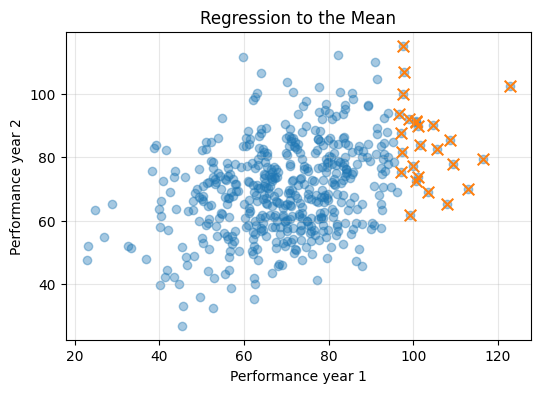

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(performance_year1, performance_year2, alpha=0.4)
plt.scatter(performance_year1[top_players], performance_year2[top_players], marker="x", s=70)
plt.xlabel("Performance year 1")
plt.ylabel("Performance year 2")
plt.title("Regression to the Mean")
plt.grid(alpha=0.3)
plt.show()

## Sampling Distribution of a Statistic

Sampling distribution adalah distribusi dari sample statistic yang dihitung dari banyak sample yang diambil dari population yang sama.

Perbedaan penting:

| Istilah | Penjelasan |
|---|---|
| Data distribution | Distribusi nilai individual dalam dataset. |
| Sampling distribution | Distribusi sample statistic dari banyak sample. |
| Sample statistic | Metric yang dihitung dari sample, misalnya mean atau median. |

Sampling distribution menunjukkan seberapa besar sample statistic dapat berubah dari satu sample ke sample lain.

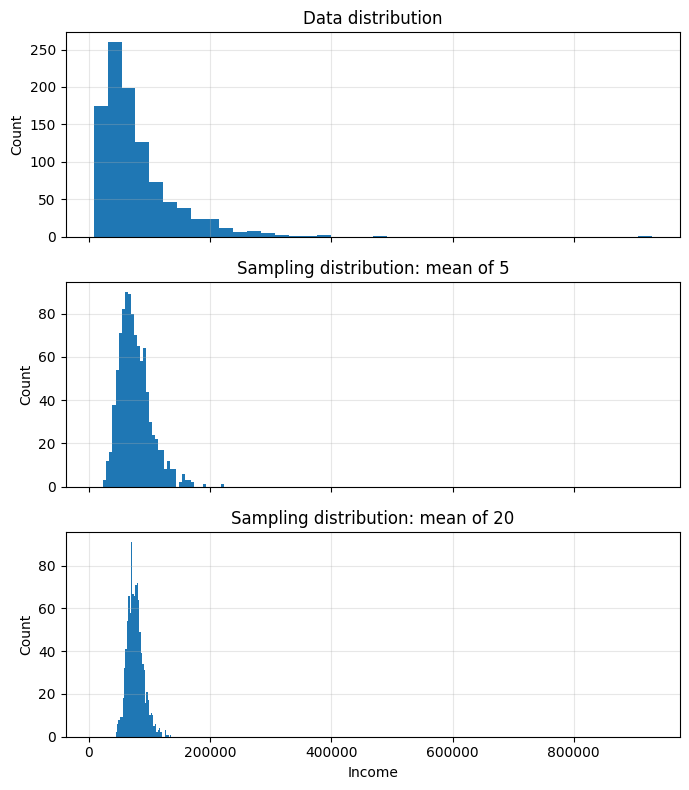

In [6]:
# Simulasi data income yang skewed
population_income = np.random.lognormal(mean=11, sigma=0.7, size=100000)

sample_data = np.random.choice(population_income, size=1000, replace=False)
sample_mean_5 = np.array([
    np.mean(np.random.choice(population_income, size=5, replace=False))
    for _ in range(1000)
])
sample_mean_20 = np.array([
    np.mean(np.random.choice(population_income, size=20, replace=False))
    for _ in range(1000)
])

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

axes[0].hist(sample_data, bins=40)
axes[0].set_title("Data distribution")

axes[1].hist(sample_mean_5, bins=40)
axes[1].set_title("Sampling distribution: mean of 5")

axes[2].hist(sample_mean_20, bins=40)
axes[2].set_title("Sampling distribution: mean of 20")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

axes[2].set_xlabel("Income")
plt.tight_layout()
plt.show()

## Central Limit Theorem

Central Limit Theorem menjelaskan bahwa distribusi dari sample means akan cenderung menyerupai normal distribution ketika sample size cukup besar, meskipun population asalnya tidak normal.

Dalam praktik data science, Central Limit Theorem penting untuk memahami sampling error. Namun, chapter juga menekankan bahwa bootstrap sering lebih praktis karena tidak bergantung kuat pada asumsi distribusi teoretis.

## Standard Error

Standard error merangkum variability dari sampling distribution untuk suatu statistic.

### Rumus Standard Error

$$
SE =
\frac{s}{\sqrt{n}}
$$

Keterangan:

- $SE$ = standard error
- $s$ = standard deviation dari sample values
- $n$ = sample size

Standard error berbeda dari standard deviation. Standard deviation mengukur variasi individual data points, sedangkan standard error mengukur variasi sample statistic antar sample.

In [7]:
sample = np.random.choice(population_income, size=100, replace=False)

std_dev = np.std(sample, ddof=1)
standard_error = std_dev / np.sqrt(len(sample))

print("Standard deviation:", round(std_dev, 2))
print("Standard error:", round(standard_error, 2))

Standard deviation: 52019.62
Standard error: 5201.96


## The Bootstrap

Bootstrap adalah metode untuk mengestimasi sampling distribution dengan mengambil resample dari observed data secara with replacement. Bootstrap tidak harus mengasumsikan data atau statistic mengikuti normal distribution.

Algoritma bootstrap untuk mean:

1. Ambil satu nilai dari sample, catat, lalu kembalikan.
2. Ulangi sampai ukuran resample sama dengan ukuran sample awal.
3. Hitung mean dari resample.
4. Ulangi proses tersebut sebanyak $R$ kali.
5. Gunakan hasil $R$ resample untuk menghitung standard error, histogram, atau confidence interval.

In [8]:
original_sample = np.random.choice(population_income, size=200, replace=False)

bootstrap_means = []

for _ in range(1000):
    resample = np.random.choice(original_sample, size=len(original_sample), replace=True)
    bootstrap_means.append(np.mean(resample))

bootstrap_means = np.array(bootstrap_means)

print("Original sample mean:", round(np.mean(original_sample), 2))
print("Bootstrap bias:", round(np.mean(bootstrap_means) - np.mean(original_sample), 2))
print("Bootstrap standard error:", round(np.std(bootstrap_means, ddof=1), 2))

Original sample mean: 74417.85
Bootstrap bias: 166.01
Bootstrap standard error: 4368.59


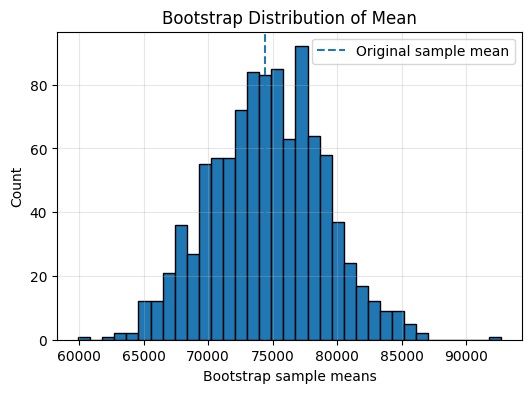

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(bootstrap_means, bins=35, edgecolor="black")
plt.axvline(np.mean(original_sample), linestyle="--", label="Original sample mean")
plt.xlabel("Bootstrap sample means")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Mean")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Resampling Versus Bootstrapping

Resampling adalah istilah umum untuk proses mengambil sample berulang dari observed data. Bootstrap adalah salah satu bentuk resampling yang selalu menggunakan sampling with replacement.

Permutation procedures juga termasuk resampling, tetapi biasanya melibatkan penggabungan sample dan pengacakan label atau nilai tanpa replacement.

## Confidence Intervals

Confidence interval menyajikan estimate dalam bentuk rentang, bukan satu angka tunggal. Rentang ini membantu menyampaikan ketidakpastian dari sample estimate.

Bootstrap confidence interval dapat dibuat dari distribusi bootstrap. Untuk confidence interval 90%, bagian 5% terbawah dan 5% teratas dari hasil bootstrap dipotong, sehingga endpoint interval adalah percentile ke-5 dan ke-95.

In [10]:
ci_90 = np.percentile(bootstrap_means, [5, 95])
ci_95 = np.percentile(bootstrap_means, [2.5, 97.5])

print("90% bootstrap confidence interval:", np.round(ci_90, 2))
print("95% bootstrap confidence interval:", np.round(ci_95, 2))

90% bootstrap confidence interval: [67365.78 81612.97]
95% bootstrap confidence interval: [66097.38 83373.72]


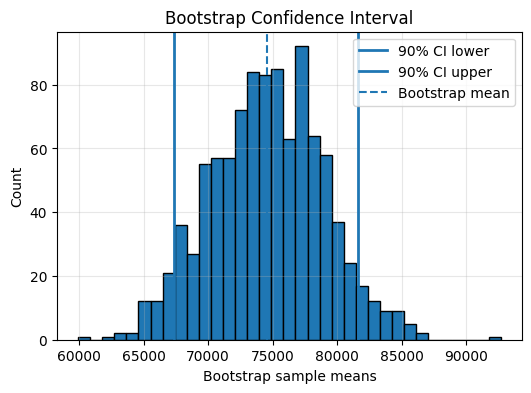

In [11]:
plt.figure(figsize=(6, 4))
plt.hist(bootstrap_means, bins=35, edgecolor="black")
plt.axvline(ci_90[0], linewidth=2, label="90% CI lower")
plt.axvline(ci_90[1], linewidth=2, label="90% CI upper")
plt.axvline(np.mean(bootstrap_means), linestyle="--", label="Bootstrap mean")
plt.xlabel("Bootstrap sample means")
plt.ylabel("Count")
plt.title("Bootstrap Confidence Interval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Normal Distribution

Normal distribution adalah distribusi berbentuk bell curve yang sangat penting dalam statistik klasik. Dalam normal distribution:

- sekitar 68% data berada dalam 1 standard deviation dari mean,
- sekitar 95% data berada dalam 2 standard deviations dari mean,
- sekitar 99.7% data berada dalam 3 standard deviations dari mean.

Chapter menekankan bahwa raw data dalam data science sering tidak normal. Kegunaan normal distribution terutama muncul karena banyak sample statistic memiliki sampling distribution yang mendekati normal.

## Standard Normal dan Z-Score

Standard normal distribution memiliki mean 0 dan standard deviation 1. Standardisasi dilakukan dengan mengurangi mean dan membagi standard deviation.

### Rumus Z-Score

$$
z =
\frac{x-\bar{x}}{s}
$$

Keterangan:

- $z$ = z-score
- $x$ = nilai data
- $\bar{x}$ = mean sample
- $s$ = standard deviation sample

Z-score menunjukkan posisi suatu nilai relatif terhadap mean dalam satuan standard deviation.

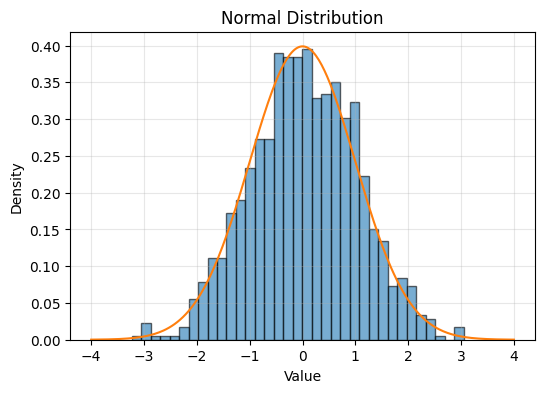

In [12]:
normal_sample = np.random.normal(loc=0, scale=1, size=1000)

x_grid = np.linspace(-4, 4, 300)
normal_pdf = stats.norm.pdf(x_grid)

plt.figure(figsize=(6, 4))
plt.hist(normal_sample, bins=35, density=True, alpha=0.6, edgecolor="black")
plt.plot(x_grid, normal_pdf)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Normal Distribution")
plt.grid(alpha=0.3)
plt.show()

## QQ-Plot

QQ-Plot digunakan untuk melihat apakah sample mendekati distribusi tertentu, misalnya normal distribution. Jika data mengikuti distribusi pembanding, titik-titik pada QQ-Plot akan berada dekat dengan garis diagonal.

QQ-Plot berguna untuk membedakan data yang normal di bagian tengah tetapi memiliki ekor yang panjang.

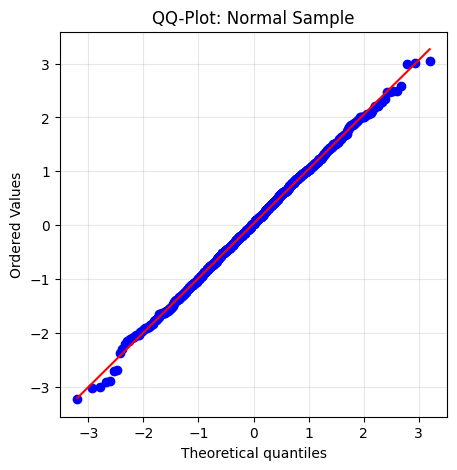

In [13]:
plt.figure(figsize=(5, 5))
stats.probplot(normal_sample, dist="norm", plot=plt)
plt.title("QQ-Plot: Normal Sample")
plt.grid(alpha=0.3)
plt.show()

## Long-Tailed Distributions

Long-tailed distribution memiliki ekor panjang, yaitu nilai ekstrem muncul dengan frekuensi rendah tetapi lebih sering daripada yang diprediksi oleh normal distribution. Banyak data nyata tidak normal dan memiliki long tails, seperti income data atau stock returns.

Pada QQ-Plot, long-tailed data terlihat dari titik-titik yang menyimpang dari garis diagonal di bagian ekor bawah dan ekor atas.

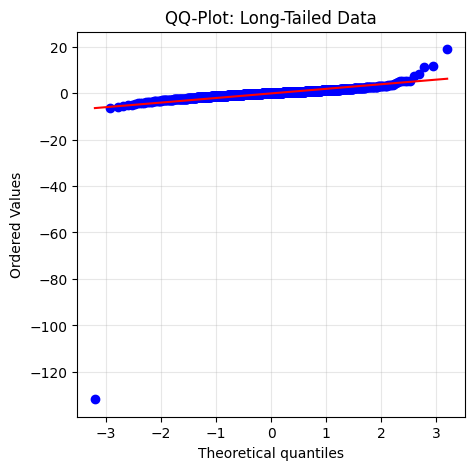

In [14]:
long_tailed_sample = stats.t(df=3).rvs(size=1000, random_state=2024)

plt.figure(figsize=(5, 5))
stats.probplot(long_tailed_sample, dist="norm", plot=plt)
plt.title("QQ-Plot: Long-Tailed Data")
plt.grid(alpha=0.3)
plt.show()

## Student's t-Distribution

t-distribution adalah keluarga distribusi yang mirip normal distribution, tetapi memiliki ekor yang lebih tebal. Distribusi ini digunakan dalam statistik klasik untuk sample kecil dan ketika population standard deviation tidak diketahui.

Chapter menekankan bahwa t-distribution tidak terlalu sentral dalam praktik data science modern karena bootstrap sering dapat menjawab banyak pertanyaan tentang sampling error. Namun, t-statistic masih sering muncul dalam output software statistik, A/B test, dan regression.

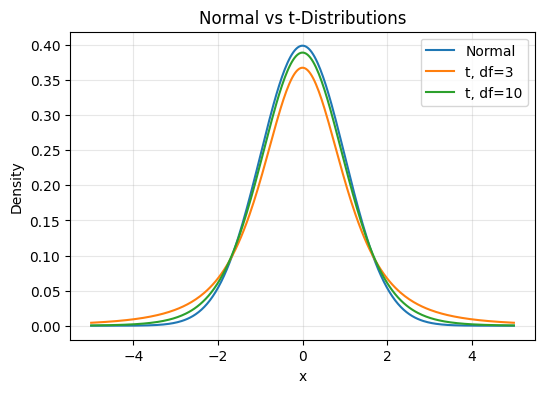

In [15]:
x = np.linspace(-5, 5, 300)

plt.figure(figsize=(6, 4))
plt.plot(x, stats.norm.pdf(x), label="Normal")
plt.plot(x, stats.t(df=3).pdf(x), label="t, df=3")
plt.plot(x, stats.t(df=10).pdf(x), label="t, df=10")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Normal vs t-Distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Binomial Distribution

Binomial distribution digunakan untuk menghitung jumlah successes dalam sejumlah trials dengan dua outcome. Contoh outcome binary adalah click/don't click, buy/don't buy, fraud/no fraud, atau survive/die.

### Rumus Binomial Probability

$$
P(X=k) =
\binom{n}{k}p^k(1-p)^{n-k}
$$

Keterangan:

- $X$ = jumlah successes
- $k$ = jumlah successes tertentu
- $n$ = jumlah trials
- $p$ = probability success pada setiap trial

Chapter memberi contoh pertanyaan seperti: jika probability konversi adalah 0.02, berapa probability mendapat 0 sales dari 200 clicks?

In [16]:
n_trials = 200
p_success = 0.02

prob_zero_sales = stats.binom.pmf(0, n_trials, p_success)
prob_two_or_fewer = stats.binom.cdf(2, n_trials, p_success)

print("P(0 sales in 200 clicks):", round(prob_zero_sales, 4))
print("P(2 or fewer sales in 200 clicks):", round(prob_two_or_fewer, 4))

P(0 sales in 200 clicks): 0.0176
P(2 or fewer sales in 200 clicks): 0.2351


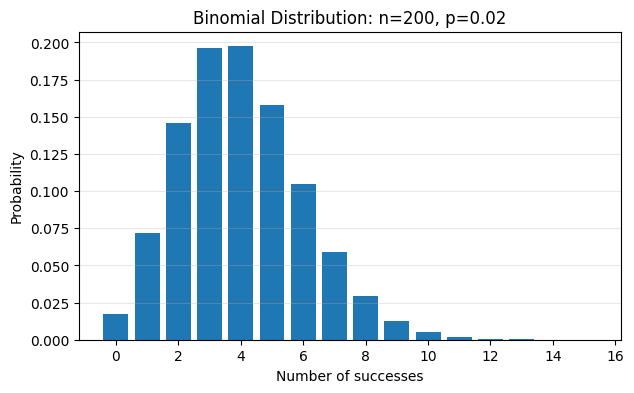

In [17]:
k_values = np.arange(0, 16)
binom_probs = stats.binom.pmf(k_values, n_trials, p_success)

plt.figure(figsize=(7, 4))
plt.bar(k_values, binom_probs)
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution: n=200, p=0.02")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Chi-Square Distribution

Chi-square distribution berkaitan dengan count data dalam kategori. Chi-square statistic mengukur seberapa jauh observed counts menyimpang dari expected counts pada null model.

Nilai chi-square kecil menunjukkan observed values dekat dengan expected values. Nilai chi-square besar menunjukkan penyimpangan yang lebih kuat dari model yang diharapkan.

## Rumus Chi-Square Statistic

$$
\chi^2 =
\sum
\frac{
(O_i-E_i)^2
}{E_i}
$$

Keterangan:

- $O_i$ = observed count kategori ke-$i$
- $E_i$ = expected count kategori ke-$i$
- $\chi^2$ = chi-square statistic

Chapter menghubungkan chi-square distribution dengan goodness-of-fit dan perbandingan beberapa treatment dalam bentuk count.

In [18]:
observed = np.array([38, 27, 35])
expected = np.array([33.33, 33.33, 33.33])

chi_square_stat = np.sum((observed - expected)**2 / expected)

print("Chi-square statistic:", round(chi_square_stat, 3))

Chi-square statistic: 1.94


## F-Distribution

F-distribution digunakan dalam eksperimen dan linear models dengan measured data. F-statistic membandingkan variasi antar group means dengan variasi dalam setiap group.

Dalam ANOVA, F-statistic digunakan untuk melihat apakah perbedaan antar groups lebih besar daripada yang mungkin muncul dari random variation.

## Rumus F-Statistic

Secara konseptual, F-statistic ditulis sebagai:

$$
F =
\frac{
\text{variability among group means}
}{
\text{variability within groups}
}
$$

Jika nilai F besar, maka perbedaan antar group means relatif besar dibanding variasi dalam group.

In [19]:
group1 = np.random.normal(10, 2, 50)
group2 = np.random.normal(12, 2, 50)
group3 = np.random.normal(14, 2, 50)

f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_value, 5))

F-statistic: 45.594
p-value: 0.0


## Poisson and Related Distributions

Poisson distribution digunakan untuk menghitung jumlah kejadian dalam interval waktu atau ruang tertentu, dengan asumsi kejadian terjadi secara independen dan pada rate rata-rata tertentu.

Contoh penggunaan:

- jumlah panggilan ke call center per jam,
- jumlah kecelakaan per hari,
- jumlah events pada server per menit.

## Rumus Poisson Probability

$$
P(X=k) =
\frac{
\lambda^k e^{-\lambda}
}{k!}
$$

Keterangan:

- $X$ = jumlah kejadian
- $k$ = jumlah kejadian tertentu
- $\lambda$ = rata-rata kejadian per interval
- $e$ = konstanta Euler

Poisson distribution cocok untuk count data yang berhubungan dengan rate kejadian.

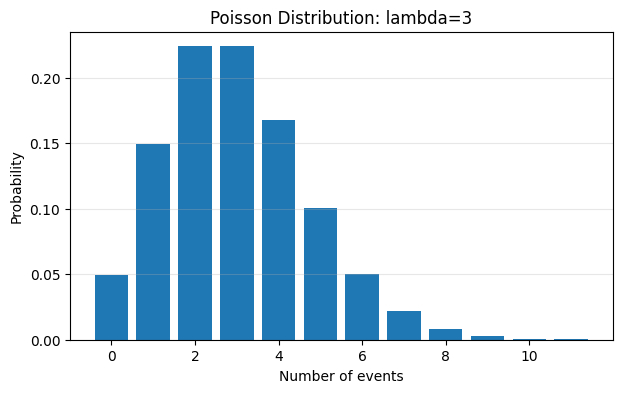

In [20]:
lam = 3
k_values = np.arange(0, 12)
poisson_probs = stats.poisson.pmf(k_values, mu=lam)

plt.figure(figsize=(7, 4))
plt.bar(k_values, poisson_probs)
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.title("Poisson Distribution: lambda=3")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Exponential Distribution

Exponential distribution berkaitan dengan waktu antar kejadian dalam proses Poisson. Jika Poisson distribution menghitung jumlah kejadian dalam interval, exponential distribution memodelkan waktu tunggu sampai kejadian berikutnya.

Contoh penggunaan:

- waktu sampai pelanggan berikutnya datang,
- waktu sampai kegagalan berikutnya,
- jarak waktu antar event.

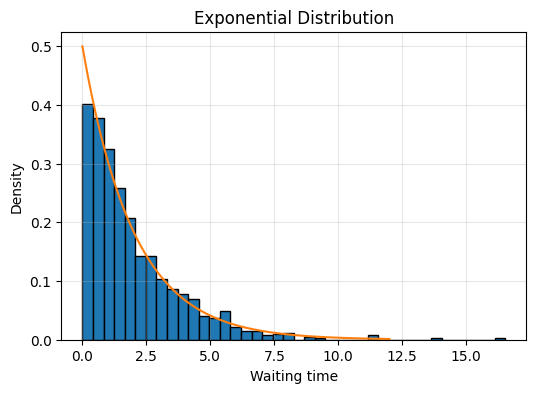

In [21]:
wait_times = stats.expon(scale=2).rvs(size=1000, random_state=2024)

plt.figure(figsize=(6, 4))
plt.hist(wait_times, bins=40, density=True, edgecolor="black")
x = np.linspace(0, 12, 300)
plt.plot(x, stats.expon(scale=2).pdf(x))
plt.xlabel("Waiting time")
plt.ylabel("Density")
plt.title("Exponential Distribution")
plt.grid(alpha=0.3)
plt.show()

## Weibull Distribution

Weibull distribution merupakan generalisasi dari exponential distribution. Distribusi ini sering digunakan untuk memodelkan waktu sampai failure, terutama ketika failure rate tidak konstan.

Jika failure rate meningkat seiring waktu, Weibull distribution dapat menggambarkan proses tersebut lebih baik daripada exponential distribution. Karena itu, Weibull distribution sering digunakan dalam reliability analysis.

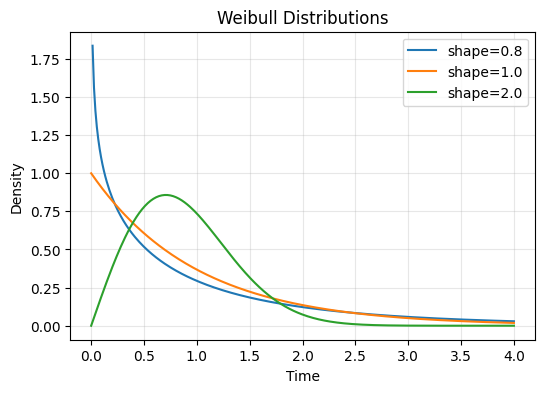

In [22]:
x = np.linspace(0, 4, 300)

plt.figure(figsize=(6, 4))
plt.plot(x, stats.weibull_min(c=0.8).pdf(x), label="shape=0.8")
plt.plot(x, stats.weibull_min(c=1.0).pdf(x), label="shape=1.0")
plt.plot(x, stats.weibull_min(c=2.0).pdf(x), label="shape=2.0")
plt.xlabel("Time")
plt.ylabel("Density")
plt.title("Weibull Distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Population | Kumpulan data besar yang menjadi sumber sample. |
| Sample | Subset dari population. |
| Random sampling | Pengambilan sample secara acak dengan peluang yang sama. |
| Stratified sampling | Sampling dari subgroup atau strata population. |
| Sample bias | Sample tidak merepresentasikan population secara sistematis. |
| Selection bias | Bias dari proses pemilihan data atau pencarian pola. |
| Regression to the mean | Nilai ekstrem cenderung diikuti nilai yang lebih dekat rata-rata. |
| Sampling distribution | Distribusi sample statistic dari banyak sample. |
| Central Limit Theorem | Sample mean cenderung normal saat sample size membesar. |
| Standard error | Variability dari sample statistic. |
| Bootstrap | Resampling with replacement dari observed data. |
| Confidence interval | Rentang estimasi yang menggambarkan ketidakpastian. |
| Normal distribution | Distribusi bell-shaped penting untuk sampling statistic. |
| Z-score | Nilai standardized dalam satuan standard deviation. |
| QQ-Plot | Visualisasi untuk membandingkan data dengan distribusi teoretis. |
| Long-tailed distribution | Distribusi dengan nilai ekstrem lebih sering muncul. |
| t-distribution | Distribusi mirip normal dengan ekor lebih tebal. |
| Binomial distribution | Distribusi jumlah successes dalam trials binary. |
| Chi-square distribution | Distribusi statistic untuk count data dan goodness-of-fit. |
| F-distribution | Distribusi statistic untuk membandingkan variasi antar dan dalam group. |
| Poisson distribution | Distribusi jumlah kejadian dalam interval. |
| Exponential distribution | Distribusi waktu tunggu antar kejadian. |
| Weibull distribution | Distribusi waktu sampai failure dengan rate yang dapat berubah. |

## Kesimpulan Chapter

Chapter ini menekankan bahwa sampling tetap penting dalam data science, bahkan pada era big data. Data yang besar belum tentu representatif, sehingga random sampling dan perhatian terhadap bias tetap diperlukan.

Sample bias dan selection bias dapat menyebabkan kesimpulan yang keliru. Selection bias dapat muncul dari cara data dipilih, data snooping, atau pencarian pola berulang dalam dataset besar. Regression to the mean juga perlu dipahami agar nilai ekstrem tidak ditafsirkan secara berlebihan.

Sampling distribution menjelaskan bagaimana sample statistic berubah dari sample ke sample. Central Limit Theorem menjelaskan mengapa sample mean sering mendekati normal distribution ketika sample size cukup besar. Standard error digunakan untuk merangkum variability dari sample statistic.

Bootstrap menjadi alat praktis untuk mengestimasi sampling distribution, standard error, dan confidence interval tanpa asumsi distribusi teoretis yang kuat. Metode ini berguna dalam banyak situasi data science karena dapat diterapkan pada berbagai statistic dan model.

Bagian akhir chapter memperkenalkan beberapa distribusi penting. Normal distribution berperan dalam inferensi klasik, tetapi data nyata sering long-tailed. t-distribution, binomial, chi-square, F, Poisson, exponential, dan Weibull distribution digunakan untuk konteks statistik yang berbeda, seperti sample means, binary outcomes, count data, eksperimen, event rates, waiting time, dan reliability analysis.